# Z-Sampling Convergence Study — Au [110]

How does diffraction-pattern accuracy degrade as z-sampling becomes coarser?

- **Ground truth**: KG ODE with 128 slices/cell (finest z-sampling, tight tolerances)
- **Test methods**: Fresnel MS, Angular Spectrum, WPM, KG FWD Lanczos
- **Input wave**: Plane wave
- **z-samplings**: 1, 2, 4, 8, 16, 32, 128 slices/cell
- **Metric**: Relative L2 norm of diffraction pattern difference vs ground truth
- **Energy**: 200 keV, Au [110] zone axis, ~100 unit cells thick

In [1]:
%matplotlib inline

import os
from time import perf_counter
import functools

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk, surface
from matplotlib.colors import LogNorm
from tqdm.auto import tqdm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_kg_ode_full,
)
from wide_angle_propagation.propagation_methods import _lanczos_expsqrt

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Build crystal and common objects

In [ ]:
# --- Parameters ---
energy = 200e3
a_Au = 4.076

# --- Build Au [110] orthogonal cell ---
au_bulk = bulk("Au", "fcc", a=a_Au)
au_110 = surface(au_bulk, (1, 1, 0), layers=2)
unit_cell = abtem.orthogonalize_cell(au_110)

z_period = a_Au / np.sqrt(2)
unit_cell.cell[2, 2] = z_period
unit_cell.pbc = [True, True, True]

nx = int(np.ceil(10 / unit_cell.cell.lengths()[0]))
ny = int(np.ceil(10 / unit_cell.cell.lengths()[1]))
nz = int(np.ceil(100 / z_period))

supercell = unit_cell * (nx, ny, nz)
total_thickness = float(supercell.cell[2, 2])

wavelength = energy2wavelength(energy)
print(f"Au [110], {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Unit cell z-period = {z_period:.4f} Å")
print(f"Supercell: {nx}×{ny}×{nz}, total thickness = {total_thickness:.1f} Å")

# --- Z-sampling levels ---
slices_per_cell_list = [1, 2, 4, 8, 16, 32, 128]
dz_list = [z_period / s for s in slices_per_cell_list]

print(f"\n{'Slices/cell':>12s} {'dz (Å)':>10s} {'Total slices':>14s}")
print("-" * 38)
for spc, dz in zip(slices_per_cell_list, dz_list):
    n_sl = int(np.round(total_thickness / dz))
    print(f"{spc:>12d} {dz:>10.4f} {n_sl:>14d}")

Au [110], 200 keV, λ = 0.0251 Å
Unit cell z-period = 2.8836 Å
Supercell: 4×4×35, total thickness = 100.9 Å

 Slices/cell     dz (Å)   Total slices
--------------------------------------
           1     2.8836             35
           2     1.4418             70
           4     0.7209            140
           8     0.3604            280
          16     0.1802            560
          32     0.0901           1120
         128     0.0225           4480


## KG FWD Lanczos propagator helper

In [3]:
def simulate_kg_fwd_lanczos(pot_arr, psi_0, dz, E, samp, lanczos_m=130):
    ny, nx = psi_0.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(E)) ** 2
    dy, dx = samp
    fy = jnp.fft.fftfreq(ny, d=dy)
    fx = jnp.fft.fftfreq(nx, d=dx)
    Fx, Fy = jnp.meshgrid(fx, fy)
    kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2
    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, E) ** 2)(pot_arr)
    probe_k = jnp.fft.fft2(jnp.asarray(psi_0, dtype=jnp.complex128)) / (ny * nx)
    state = probe_k.ravel()

    @functools.partial(jax.jit, static_argnums=(4, 5, 6))
    def _propagate_one_slice(s, n_sq, k0sq, kpsq, ny_, nx_, m_):
        def matvec(v):
            vg = v.reshape(ny_, nx_)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0sq * conv - kpsq * vg).ravel()
        return _lanczos_expsqrt(matvec, s, dz, m_)

    for i in range(pot_arr.shape[0]):
        state = _propagate_one_slice(state, n_sq_all[i], k0_sq, kp_sq, ny, nx, lanczos_m)

    exit_k = state.reshape(ny, nx)
    exit_wave = jnp.fft.ifft2(exit_k) * (ny * nx)
    return np.asarray(exit_wave)

print("Lanczos propagator defined.")

Lanczos propagator defined.


## Compute ground truth — KG ODE at 128 slices/cell

In [4]:
ref_slices_per_cell = slices_per_cell_list[-1]  # 128
ref_dz = z_period / ref_slices_per_cell
ref_n_slices = int(np.round(total_thickness / ref_dz))

print(f"Ground truth: KG ODE, dz = {ref_dz:.4f} Å, {ref_n_slices} slices")
print("Building potential...")

pot_ref_abtem = abtem.Potential(
    supercell, sampling=0.1, slice_thickness=ref_dz,
    projection="finite", parametrization="lobato",
)
gpts = tuple(pot_ref_abtem.gpts)
sampling = (float(pot_ref_abtem.sampling[0]), float(pot_ref_abtem.sampling[1]))

pot_ref_arr = jnp.array(cupy.asnumpy(pot_ref_abtem.build(lazy=False).array / ref_dz))

ny, nx = pot_ref_arr.shape[1:]
probe_array = jnp.ones((ny, nx), dtype=jnp.complex128)

del pot_ref_abtem
cupy.get_default_memory_pool().free_all_blocks()

print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Potential shape: {pot_ref_arr.shape}")
print(f"\nRunning KG ODE ground truth (rtol=1e-9, atol=1e-11)...")

t0 = perf_counter()
ew_gt, _, dp_gt_raw, _ = simulate_kg_ode_full(
    pot_ref_arr, probe_array, ref_dz, energy, sampling,
    rtol=1e-9, atol=1e-11,
)
dp_gt = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(ew_gt)))) ** 2
t_gt = perf_counter() - t0

del pot_ref_arr
print(f"Done in {t_gt:.1f}s, DP max: {dp_gt.max():.4e}")

Ground truth: KG ODE, dz = 0.0225 Å, 4480 slices
Building potential...
Grid: (116, 116), sampling = (0.0994, 0.0994) Å
Potential shape: (4480, 116, 116)

Running KG ODE ground truth (rtol=1e-9, atol=1e-11)...
Done in 90.0s, DP max: 6.6297e+07


## Sweep z-sampling for all 4 methods

For each slice thickness, rebuild the potential and run all methods.
Compare diffraction patterns against ground truth.

In [5]:
method_names = ["Fresnel MS", "Angular Spectrum", "WPM", "KG FWD Lanczos"]

rel_l2_results = {name: [] for name in method_names}
rms_results = {name: [] for name in method_names}
timings = {name: [] for name in method_names}

for spc, dz in zip(slices_per_cell_list, dz_list):
    n_slices = int(np.round(total_thickness / dz))
    print(f"\n{'='*60}")
    print(f"dz = {dz:.4f} Å ({spc} slices/cell, {n_slices} total slices)")
    print(f"{'='*60}")

    pot_abtem = abtem.Potential(
        supercell, gpts=gpts, slice_thickness=dz,
        projection="finite", parametrization="lobato",
    )
    pot_arr = jnp.array(cupy.asnumpy(pot_abtem.build(lazy=False).array / dz))
    del pot_abtem
    cupy.get_default_memory_pool().free_all_blocks()

    fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz, energy=energy))
    ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz, energy=energy))

    methods_to_run = {
        "Fresnel MS":       lambda: simulate_fresnel_as(pot_arr, probe_array, fk, dz, energy),
        "Angular Spectrum": lambda: simulate_fresnel_as(pot_arr, probe_array, ak, dz, energy),
        "WPM":              lambda: simulate_wpm(pot_arr, probe_array, dz, energy, sampling),
        "KG FWD Lanczos":   lambda: (simulate_kg_fwd_lanczos(pot_arr, probe_array, dz, energy, sampling), None, None),
    }

    for name in method_names:
        print(f"  {name}...", end=" ", flush=True)
        t0 = perf_counter()
        result = methods_to_run[name]()
        elapsed = perf_counter() - t0

        ew = np.asarray(result[0])
        dp = np.abs(np.fft.fftshift(np.fft.fft2(ew))) ** 2
        dp_diff = dp - dp_gt
        rel_l2 = float(np.linalg.norm(dp_diff) / np.linalg.norm(dp_gt))
        rms = float(np.sqrt(np.mean(dp_diff**2)))

        rel_l2_results[name].append(rel_l2)
        rms_results[name].append(rms)
        timings[name].append(elapsed)

        print(f"{elapsed:.1f}s, Rel L2 = {rel_l2:.4e}")

    del pot_arr, fk, ak

print(f"\n{'='*60}")
print("Sweep complete.")


dz = 2.8836 Å (1 slices/cell, 35 total slices)
  Fresnel MS... 0.4s, Rel L2 = 1.4668e-02
  Angular Spectrum... 0.1s, Rel L2 = 1.2874e-02
  WPM... 2.4s, Rel L2 = 1.3240e-02
  KG FWD Lanczos... 1.8s, Rel L2 = 1.8257e-01

dz = 1.4418 Å (2 slices/cell, 70 total slices)
  Fresnel MS... 0.4s, Rel L2 = 3.3631e-02
  Angular Spectrum... 0.2s, Rel L2 = 3.3873e-02
  WPM... 1.6s, Rel L2 = 3.4563e-02
  KG FWD Lanczos... 2.0s, Rel L2 = 1.5012e-01

dz = 0.7209 Å (4 slices/cell, 140 total slices)
  Fresnel MS... 0.6s, Rel L2 = 1.6026e-02
  Angular Spectrum... 0.4s, Rel L2 = 1.7206e-02
  WPM... 3.1s, Rel L2 = 1.7744e-02
  KG FWD Lanczos... 2.7s, Rel L2 = 6.6833e-02

dz = 0.3604 Å (8 slices/cell, 280 total slices)
  Fresnel MS... 1.1s, Rel L2 = 2.0103e-02
  Angular Spectrum... 0.8s, Rel L2 = 1.2156e-02
  WPM... 6.2s, Rel L2 = 1.2533e-02
  KG FWD Lanczos... 4.2s, Rel L2 = 1.2162e-02

dz = 0.1802 Å (16 slices/cell, 560 total slices)
  Fresnel MS... 1.1s, Rel L2 = 1.2237e-02
  Angular Spectrum... 0.9s, Re

## Convergence plot

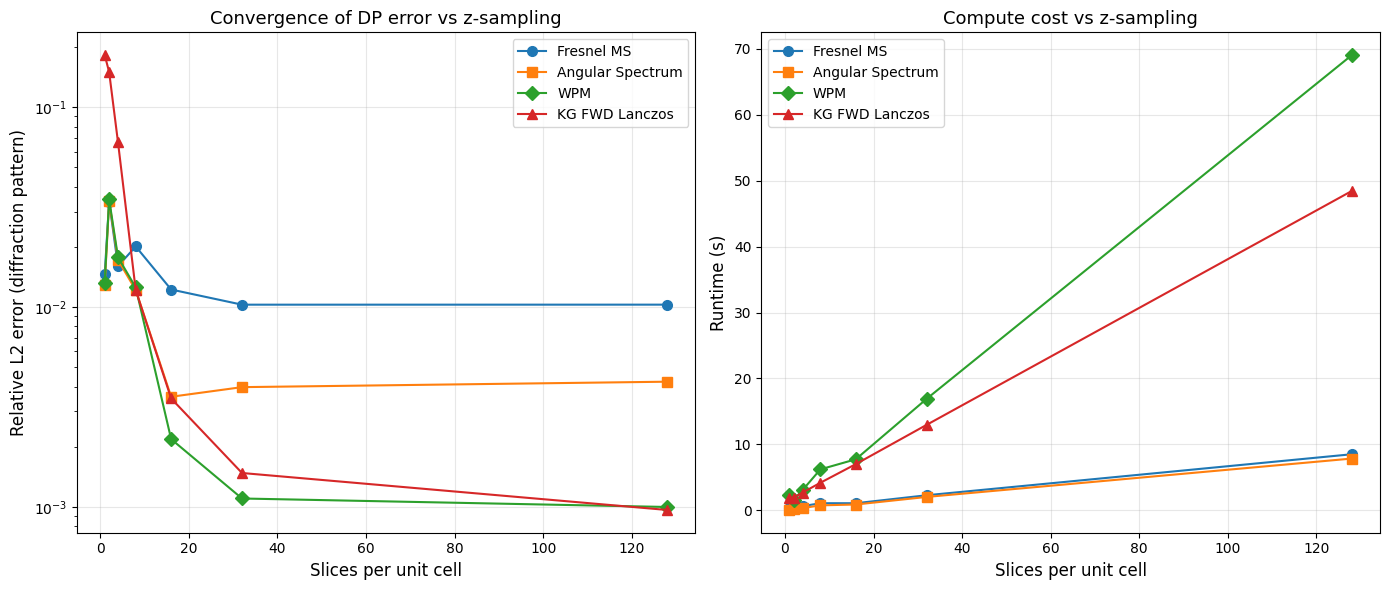

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

markers = {'Fresnel MS': 'o', 'Angular Spectrum': 's', 'WPM': 'D', 'KG FWD Lanczos': '^'}
colors = {'Fresnel MS': 'C0', 'Angular Spectrum': 'C1', 'WPM': 'C2', 'KG FWD Lanczos': 'C3'}

spc_arr = np.array(slices_per_cell_list)

# Left: Rel L2 vs slices/cell
for name in method_names:
    ax1.semilogy(spc_arr, rel_l2_results[name], f'-{markers[name]}',
                 color=colors[name], label=name, markersize=7, linewidth=1.5)

ax1.set_xlabel("Slices per unit cell", fontsize=12)
ax1.set_ylabel("Relative L2 error (diffraction pattern)", fontsize=12)
ax1.set_title("Convergence of DP error vs z-sampling", fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Right: runtime vs slices/cell
for name in method_names:
    ax2.plot(spc_arr, timings[name], f'-{markers[name]}',
             color=colors[name], label=name, markersize=7, linewidth=1.5)

ax2.set_xlabel("Slices per unit cell", fontsize=12)
ax2.set_ylabel("Runtime (s)", fontsize=12)
ax2.set_title("Compute cost vs z-sampling", fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Summary table

In [7]:
print(f"Au [110], {energy/1e3:.0f} keV, {total_thickness:.0f} Å")
print(f"Ground truth: KG ODE at dz = {ref_dz:.4f} Å ({ref_slices_per_cell} slices/cell)\n")

hdr = f"{'dz (Å)':>8s} {'sl/cell':>8s}"
for name in method_names:
    hdr += f" {name:>17s}"
print(hdr)
print("-" * len(hdr))

for i, (spc, dz) in enumerate(zip(slices_per_cell_list, dz_list)):
    row = f"{dz:>8.4f} {spc:>8d}"
    for name in method_names:
        row += f" {rel_l2_results[name][i]:>17.4e}"
    print(row)

Au [110], 200 keV, 101 Å
Ground truth: KG ODE at dz = 0.0225 Å (128 slices/cell)

  dz (Å)  sl/cell        Fresnel MS  Angular Spectrum               WPM    KG FWD Lanczos
-----------------------------------------------------------------------------------------
  2.8836        1        1.4668e-02        1.2874e-02        1.3240e-02        1.8257e-01
  1.4418        2        3.3631e-02        3.3873e-02        3.4563e-02        1.5012e-01
  0.7209        4        1.6026e-02        1.7206e-02        1.7744e-02        6.6833e-02
  0.3604        8        2.0103e-02        1.2156e-02        1.2533e-02        1.2162e-02
  0.1802       16        1.2237e-02        3.5545e-03        2.1805e-03        3.4854e-03
  0.0901       32        1.0275e-02        3.9712e-03        1.1001e-03        1.4760e-03
  0.0225      128        1.0278e-02        4.2286e-03        9.9759e-04        9.6372e-04
